Introduction to Neural Networks

In [1]:
import numpy as np
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader, random_split

import seaborn as sns

# MNIST dataset

In [2]:
def load_mnist_dataset(mnist_path):
    x_trainval = get_images(Path(mnist_path)/Path('train-images-idx3-ubyte.gz'))
    y_trainval = get_labels(Path(mnist_path)/Path('train-labels-idx1-ubyte.gz'))

    x_train = x_trainval[:50000]
    y_train = y_trainval[:50000]

    x_val = x_trainval[50000:]
    y_val = y_trainval[50000:]

    x_test = get_images(Path(mnist_path)/Path('t10k-images-idx3-ubyte.gz'))
    y_test = get_labels(Path(mnist_path)/Path('t10k-labels-idx1-ubyte.gz'))

    return x_train, y_train, x_val, y_val, x_test, y_test

def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))

In [3]:
x_train, y_train, x_val, y_val, x_test, y_test = load_mnist_dataset('./data/mnist')

Establecemos los datos de prueba, validacion y entrenamiento. Tambien nos saltamos los 8 bytes de cabecera de los archivos "me imagino que es porque no los necesitamos"
Al final ajustamos el tamaño de las imagenes a 28x28, esto a las 60,000 imagenes.

In [4]:
x_train = x_train.copy().reshape(50000, -1).astype(np.float32)
y_train = y_train.copy().reshape(50000, 1)

x_val = x_val.copy().reshape(10000, -1).astype(np.float32)
y_val = y_val.copy().reshape(10000, 1)

x_test = x_test.copy().reshape(10000, -1).astype(np.float32)
y_test = y_test.copy().reshape(10000, 1)

Convertimos las imagenes a vectores de 784 pixeles a flotantes y las etiquetas a columnas tipo int

In [5]:
class MNISTDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y.squeeze(), dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

#Generamos datasets
train_dataset = MNISTDataset(x_train, y_train)  # 50,000
val_dataset   = MNISTDataset(x_val, y_val)       # 10,000
test_dataset  = MNISTDataset(x_test, y_test)     # 10,000

#Dividir en mini-batches automáticamente
#Mezclar los datos en cada época (shuffle)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)


Necesitas crear una clase que herede de Dataset, para poder utilizar pytorch    

In [6]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

# Defining the Neural Network

In [7]:
import torch.nn as nn
class NeuralNetwork(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 10)
        )

    def forward(self, x):
        return self.net(x)


No hace falta definir backward ni update, ya que PyTorch lo hace por nosotros.

Training the Neural Network

In [8]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss() # Función de pérdida para clasificación multiclase

Establecemos la función de perdida, la cual internamente aplica softmax + cross entropy.


In [9]:
from tqdm import tqdm

def train_model(model, optimizer, train_loader, val_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):

        model.train() 
        
        # tqdm crea la barra de progreso iterando sobre el train_loader
        epoch_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
        
        train_loss = 0.0
        
        for x_batch, y_batch in epoch_iterator:
            optimizer.zero_grad()               # 1. Limpiamos gradientes anteriores
            output = model(x_batch)             # 2. Pasamos los datos por la red (forward)
            loss = criterion(output, y_batch)   # 3. Calculamos qué tan mal lo hizo (loss)
            loss.backward()                     # 4. Calcula gradientes (backward)
            optimizer.step()                    # 5. El optimizador ajusta los pesos
            train_loss = loss.item()            # Guardamos el loss actual para mostrarlo
            epoch_iterator.set_postfix(train_loss=f"{train_loss:.4f}")
            
        model.eval()
        
        val_loss = 0.0
        correct = 0
        total = 0
        
        # torch.no_grad() apaga el cálculo de gradientes
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                output = model(x_batch)                      # 1. Obtenemos predicciones crudas
                loss = criterion(output, y_batch)            # 2. Calculamos el loss de validación
                
                val_loss += loss.item() * x_batch.size(0)    # Acumulamos el loss ponderado
                
                # Calculamos accuracy
                predictions = output.argmax(dim=1)           # Nos quedamos con la clase de mayor score
                correct += (predictions == y_batch).sum().item() # Contamos aciertos
                total += y_batch.size(0)                     # Contamos total de ejemplos
                
        # Calculamos promedios finales de validación
        val_loss = val_loss / total
        val_acc = correct / total
        
        print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}\n")
    return model



Definimos como es que vamos a realizar el entrenamiento. Se utiliza en funcion porque se llamara para cada modelo con diferentes valores de variables.

In [10]:
print("================ MODELO 1 ================")
# Arquitectura: 1 capa oculta de 200 neuronas
model1 = NeuralNetwork(hidden_size=200)

# Optimizador: Adam, LR: 0.001
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)

# Entrenamos por 10 épocas
model1 = train_model(model1, optimizer1, train_loader, val_loader, epochs=10)

================ MODELO 1 ================


Epoch 1/10: 100%|██████████| 196/196 [00:01<00:00, 138.13it/s, train_loss=0.1120]


Val Loss: 0.2536 | Val Accuracy: 0.9416



Epoch 2/10: 100%|██████████| 196/196 [00:01<00:00, 167.73it/s, train_loss=0.2184]


Val Loss: 0.1854 | Val Accuracy: 0.9540



...

Val Loss: 0.1583 | Val Accuracy: 0.9673



Epoch 9/10: 100%|██████████| 196/196 [00:01<00:00, 172.61it/s, train_loss=0.0087]


Val Loss: 0.1770 | Val Accuracy: 0.9664



Epoch 10/10: 100%|██████████| 196/196 [00:01<00:00, 185.62it/s, train_loss=0.0258]


Val Loss: 0.1590 | Val Accuracy: 0.9705



In [24]:
print("================ MODELO 2 ================")
# Arquitectura mejorada: 1 capa de 128 neuronas 
model2 = NeuralNetwork(hidden_size=128)

# Optimizador: SGD, pero bajamos el Learning Rate a 0.01
optimizer2 = optim.SGD(model2.parameters(), lr=0.01)

# Entrenamos por 15 épocas
model2 = train_model(model2, optimizer2, train_loader, val_loader, epochs=15)


================ MODELO 2 ================


Epoch 1/15: 100%|██████████| 196/196 [00:01<00:00, 183.86it/s, train_loss=1.5238]


Val Loss: 1.3316 | Val Accuracy: 0.5797



Epoch 2/15: 100%|██████████| 196/196 [00:00<00:00, 242.11it/s, train_loss=2.4459]


Val Loss: 2.3110 | Val Accuracy: 0.3216



...

Val Loss: 1.3039 | Val Accuracy: 0.5083



Epoch 14/15: 100%|██████████| 196/196 [00:00<00:00, 248.79it/s, train_loss=1.5225]


Val Loss: 1.3624 | Val Accuracy: 0.4803



Epoch 15/15: 100%|██████████| 196/196 [00:00<00:00, 217.57it/s, train_loss=1.8673]


Val Loss: 1.9290 | Val Accuracy: 0.2825



In [12]:
class NeuralNetworkM3(nn.Module):
    def __init__(self, hidden_size=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, hidden_size * 2),   # 784 → 512
            nn.ReLU(),
            nn.Linear(hidden_size * 2, hidden_size),      # 512 → 256
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),     # 256 → 128
            nn.ReLU(),
            nn.Linear(hidden_size // 2, 10)               # 128 → 10
        )
 
    def forward(self, x):
        return self.net(x)

In [13]:
def train_model_early_stop(model, optimizer, train_loader, val_loader, epochs=50, patience=3, delta=0.005):
    criterion = nn.CrossEntropyLoss()
    val_losses = [] # Lista para almacenar el val_loss histórico

    for epoch in range(epochs):
        model.train() 
        epoch_iterator = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
        train_loss = 0.0
        
        for x_batch, y_batch in epoch_iterator:
            optimizer.zero_grad()               
            output = model(x_batch)             
            loss = criterion(output, y_batch)   
            loss.backward()                     
            optimizer.step()                    
            train_loss = loss.item()            
            epoch_iterator.set_postfix(train_loss=f"{train_loss:.4f}")
            
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                output = model(x_batch)                      
                loss = criterion(output, y_batch)            
                val_loss += loss.item() * x_batch.size(0)    
                predictions = output.argmax(dim=1)           
                correct += (predictions == y_batch).sum().item() 
                total += y_batch.size(0)                     
                
        val_loss = val_loss / total
        val_acc = correct / total
        
        print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}\n")
        
        # === INICIO DE LA LÓGICA DE EARLY STOPPING === #
        val_losses.append(val_loss) # Se guarda el loss de la época "n"
        n = epoch
        
        # Se evalúa solo si han pasado suficientes iteraciones (época n >= patience)
        if n >= patience:
            loss_n_minus_patience = val_losses[n - patience]
            loss_n = val_losses[n]
            
            # 1. Condición descrita en tu ejemplo (se detiene si avanzó muy poco):
            # abs(loss(n-patience) - loss(n)) < delta y loss(n-patience) >= loss(n)
            if abs(loss_n_minus_patience - loss_n) < delta and loss_n_minus_patience >= loss_n:
                print(f"Early stop activado en la época {n+1}: La mejora fue de solo {abs(loss_n_minus_patience - loss_n):.6f} (menor al delta establecido de {delta}).")
                break
                
            # 2. (Opcional pero ideal) Si la pérdida del modelo directamente empeoró en vez de mejorar
            elif loss_n > loss_n_minus_patience:
                print(f"Early stop activado en la época {n+1}: El rendimiento empeoró respecto a la iteración anterior.")
                break
            
    return model


Para el modelo 3 vamos a utilizar otra neuralnetwork y para entrenar vamos a utilizar early stop la implementacion sera manual.

In [25]:
print("================ MODELO 3 ================")
# Con hidden_size=128
model3 = NeuralNetworkM3(hidden_size=128)

# Optimizador: Cambiamos a Adam, LR: 0.001 
optimizer3 = optim.Adam(model3.parameters(), lr=0.001)

# Entrenamos con la función de early stop, paciencia de 3 épocas
model3 = train_model_early_stop(model3, optimizer3, train_loader, val_loader, epochs=50, patience=3, delta=0.005)


================ MODELO 3 ================


Epoch 1/50: 100%|██████████| 196/196 [00:01<00:00, 132.79it/s, train_loss=0.0888]


Val Loss: 0.1712 | Val Accuracy: 0.9497



Epoch 2/50: 100%|██████████| 196/196 [00:01<00:00, 147.41it/s, train_loss=0.2241]


Val Loss: 0.1095 | Val Accuracy: 0.9685



...

Val Loss: 0.1043 | Val Accuracy: 0.9697



Epoch 4/50: 100%|██████████| 196/196 [00:01<00:00, 129.45it/s, train_loss=0.0687]


Val Loss: 0.0981 | Val Accuracy: 0.9721



Epoch 5/50: 100%|██████████| 196/196 [00:01<00:00, 136.71it/s, train_loss=0.0611]


Val Loss: 0.1217 | Val Accuracy: 0.9666

Early stop activado en la época 5: El rendimiento empeoró respecto a la iteración anterior.


Testing the model

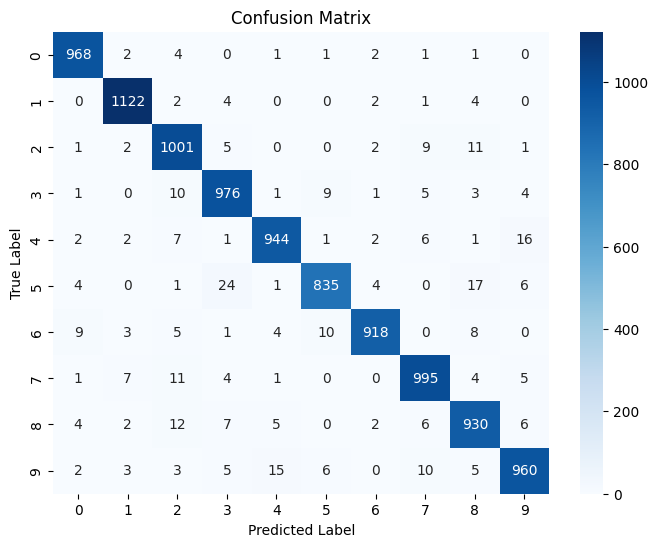

In [26]:

# 1. Recolectar todas las predicciones y etiquetas reales procesando por batches
all_preds = []
all_labels = []

model1.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        output = model1(x_batch)
        predictions = output.argmax(dim=1)

        # .cpu().numpy() convierte los tensores de PyTorch de vuelta a arrays de NumPy
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# 2. Inicializar la matriz de confusión (10x10) en ceros
conf_matrix = np.zeros((10, 10), dtype=int)

# 3. Llenar la matriz contando las coincidencias
for true_label, pred_label in zip(all_labels, all_preds):
    conf_matrix[true_label, pred_label] += 1

# 4. Graficar el resultado con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


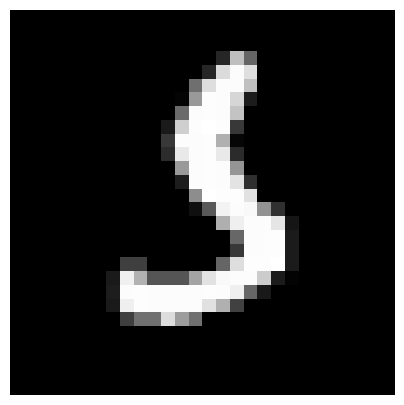

'Label: 5'

'Predicted: 3'

In [27]:
random_idx = np.random.randint(0, x_test.shape[0])
plot_number(x_test[random_idx])
display(f"Label: {y_test[random_idx].squeeze()}", f"Predicted: {all_preds[random_idx]}")

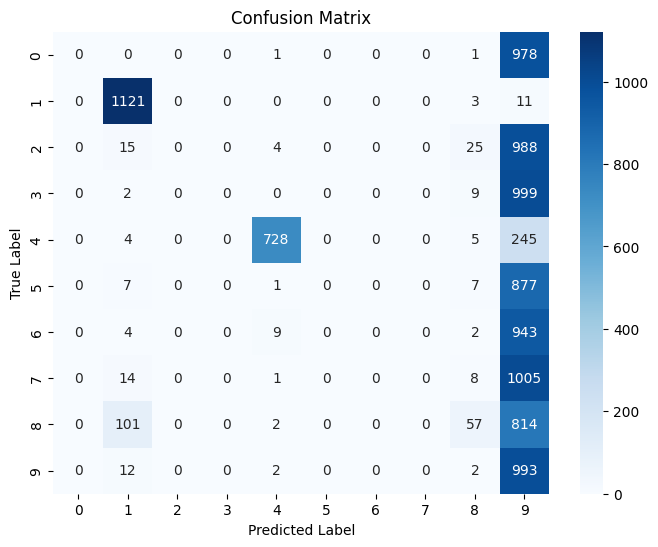

In [28]:

# 1. Recolectar todas las predicciones y etiquetas reales procesando por batches
all_preds = []
all_labels = []

model2.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        output = model2(x_batch)
        predictions = output.argmax(dim=1)
        
        # .cpu().numpy() convierte los tensores de PyTorch de vuelta a arrays de NumPy
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# 2. Inicializar la matriz de confusión (10x10) en ceros
conf_matrix = np.zeros((10, 10), dtype=int)

# 3. Llenar la matriz contando las coincidencias
for true_label, pred_label in zip(all_labels, all_preds):
    conf_matrix[true_label, pred_label] += 1

# 4. Graficar el resultado con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[str(i) for i in range(10)], 
            yticklabels=[str(i) for i in range(10)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


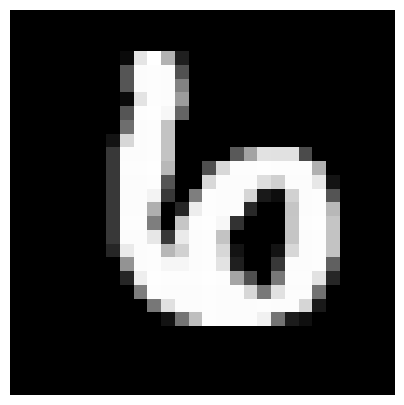

'Label: 6'

'Predicted: 9'

In [29]:
random_idx = np.random.randint(0, x_test.shape[0])
plot_number(x_test[random_idx])
display(f"Label: {y_test[random_idx].squeeze()}", f"Predicted: {all_preds[random_idx]}")

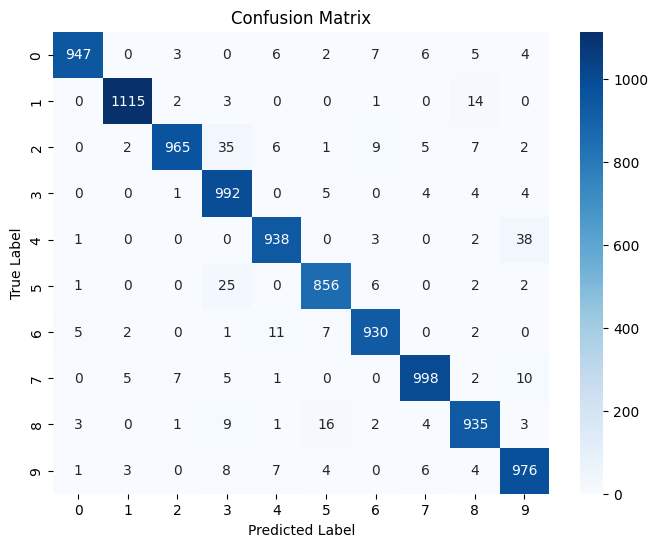

In [30]:

# 1. Recolectar todas las predicciones y etiquetas reales procesando por batches
all_preds = []
all_labels = []

model3.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        output = model3(x_batch)
        predictions = output.argmax(dim=1)
        
        # .cpu().numpy() convierte los tensores de PyTorch de vuelta a arrays de NumPy
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# 2. Inicializar la matriz de confusión (10x10) en ceros
conf_matrix = np.zeros((10, 10), dtype=int)

# 3. Llenar la matriz contando las coincidencias
for true_label, pred_label in zip(all_labels, all_preds):
    conf_matrix[true_label, pred_label] += 1

# 4. Graficar el resultado con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[str(i) for i in range(10)], 
            yticklabels=[str(i) for i in range(10)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


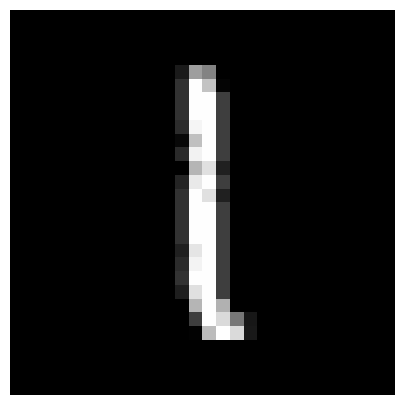

'Label: 1'

'Predicted: 1'

In [ ]:
random_idx = np.random.randint(0, x_test.shape[0])


plot_number(x_test[random_idx])
display(f"Label: {y_test[random_idx].squeeze()}", f"Predicted: {all_preds[random_idx]}")

#Reflexión Personal
     El modelo 1 fue el mejor que tuve, esto teniendo una red neuronal y entrenamiento basico. Pero al parecer los hiperparametros fueron los adecuadtos.
     El modelo 2 fue el peor, creo yo que fue por el optimizador porque en este utilice el SGD pero no logre adecuar los hiperparametros y el learning rate. El modelo 3 fue el segundo mejor, en realidad yo pensaba que seria el mejor porque tiene una arquitectura mas robusta. Pero, al parecer no. En general, siento yo que no depende tanto sobre la arquitectura, mas bien es mejor tiener una arquitectura sencilla pero con una buena combinacion de hiperparametros. En lugar de tener una arquitectura robusta con una mala combinacion de hiperparametros.